<div style="border-radius:12px; padding: 25px; background: linear-gradient(135deg, #1f2937 0%, #111827 100%); color: #ffffff; border-left: 8px solid #3b82f6; box-shadow: 0 10px 15px -3px rgba(0, 0, 0, 0.3);">
<h1 style="color: #60a5fa; margin-bottom: 5px; font-weight: 700; font-size: 28px;">Insurance Claim Fraud Detection: EDA & Baseline Model</h1>
<p style="font-size: 14px; color: #9ca3af; margin-bottom: 15px;">An interactive notebook exploring feature distributions, fraud risk flags, and building a baseline <b>XGBoost Classifier</b> on the 100k-row insurance claim dataset.</p>
<div style="margin-bottom: 20px;">
<span style="background-color: #1e3a8a; color: #93c5fd; padding: 4px 10px; border-radius: 20px; font-size: 12px; font-weight: 600; margin-right: 5px;">Dataset: 100,000 Rows</span>
<span style="background-color: #065f46; color: #a7f3d0; padding: 4px 10px; border-radius: 20px; font-size: 12px; font-weight: 600; margin-right: 5px;">Features: 61 Columns</span>
<span style="background-color: #831843; color: #fbcfe8; padding: 4px 10px; border-radius: 20px; font-size: 12px; font-weight: 600; margin-right: 5px;">Target Fraud Ratio: ~20%</span>
<span style="background-color: #374151; color: #e5e7eb; padding: 4px 10px; border-radius: 20px; font-size: 12px; font-weight: 600;">Model: XGBoost</span>
</div>
<hr style="border: 0; height: 1px; background: #374151; margin: 15px 0;">
<h3 style="color: #f3f4f6; margin-bottom: 12px; font-size: 18px;">Table of Contents</h3>
<ul style="list-style-type: none; padding-left: 0; line-height: 2;">
<li><a href="#1.-Load-Data" style="color: #60a5fa; text-decoration: none; font-weight: 600;">1. Load Data</a> <span style="color: #6b7280; font-size: 12px;">(Data loading & initial dimensions check)</span></li>
<li><a href="#2.-Exploratory-Data-Analysis-(EDA)" style="color: #60a5fa; text-decoration: none; font-weight: 600;">2. Exploratory Data Analysis (EDA)</a> <span style="color: #6b7280; font-size: 12px;">(Target distributions & risk indicators)</span></li>
<li><a href="#3.-Data-Preprocessing-&-Feature-Engineering" style="color: #60a5fa; text-decoration: none; font-weight: 600;">3. Data Preprocessing & Feature Engineering</a> <span style="color: #6b7280; font-size: 12px;">(Label encoding & train/test splits)</span></li>
<li><a href="#4.-Model-Training:-Baseline-XGBoost-Classifier" style="color: #60a5fa; text-decoration: none; font-weight: 600;">4. Model Training: Baseline XGBoost Classifier</a> <span style="color: #6b7280; font-size: 12px;">(Cost-sensitive gradient boosting)</span></li>
<li><a href="#5.-Model-Evaluation" style="color: #60a5fa; text-decoration: none; font-weight: 600;">5. Model Evaluation</a> <span style="color: #60a5fa; text-decoration: none; font-weight: 600;">(Confusion matrix & feature importance analysis)</span></li>
</ul>

In [1]:
# ==============================================================================
# Insurance Claim Fraud Detection - EDA & Baseline XGBoost Model
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, roc_curve, f1_score
)
import xgboost as xgb

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10


## 1. Load Data

In [2]:

# ------------------------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------------------------
# Note: Use keep_default_na=False so strings like 'NA' aren't read as NaN
data_path = "/kaggle/input/datasets/mobeenfatimah/insurance-claim-fraud-detection-dataset/insurance_claim_fraud_dataset.csv" 
df = pd.read_csv(data_path, keep_default_na=False)

print(f"Dataset Dimensions: {df.shape[0]:,} rows | {df.shape[1]} columns")


Dataset Dimensions: 100,000 rows | 62 columns


## 2. Exploratory Data Analysis (EDA)

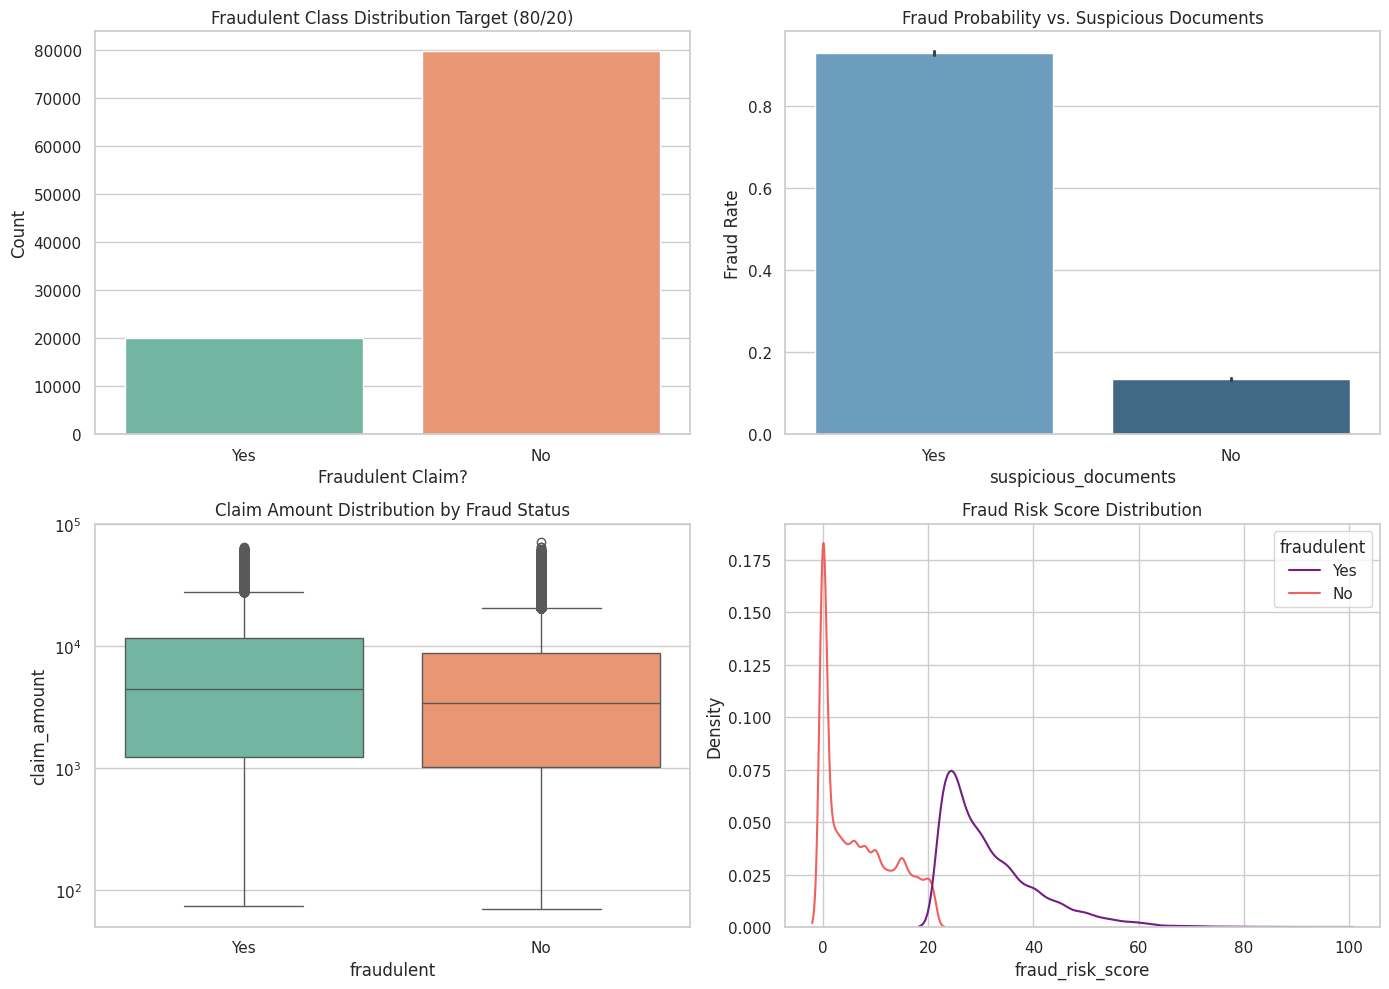

In [3]:

# ------------------------------------------------------------------------------
# 2. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Target Class Distribution
sns.countplot(x="fraudulent", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Fraudulent Class Distribution Target (80/20)")
axes[0, 0].set_xlabel("Fraudulent Claim?")
axes[0, 0].set_ylabel("Count")

# Plot 2: Fraud Rate by Suspicious Documents Indicator
sns.barplot(x="suspicious_documents", y=df["fraudulent"].map({"Yes": 1, "No": 0}), data=df, ax=axes[0, 1], palette="Blues_d")
axes[0, 1].set_title("Fraud Probability vs. Suspicious Documents")
axes[0, 1].set_ylabel("Fraud Rate")

# Plot 3: Claim Amount Distribution by Target
sns.boxplot(x="fraudulent", y="claim_amount", data=df, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Claim Amount Distribution by Fraud Status")
axes[1, 0].set_yscale("log") # Log scale for better visibility

# Plot 4: Fraud Risk Score vs Target
sns.kdeplot(data=df, x="fraud_risk_score", hue="fraudulent", common_norm=False, ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Fraud Risk Score Distribution")

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [4]:
# ------------------------------------------------------------------------------
# 3. Data Preprocessing & Feature Engineering
# ------------------------------------------------------------------------------
# Drop unique IDs and explicit target leak variables (like payout_amount/approved_amount)
drop_cols = ["claim_id", "policy_id", "customer_id", "customer_name", "payout_amount", "approved_amount"]
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Binary Target ('Yes' -> 1, 'No' -> 0)
y = df_clean["fraudulent"].map({"Yes": 1, "No": 0})
X = df_clean.drop(columns=["fraudulent"])

# Convert Date Columns to Datetime numeric features
date_cols = ["claim_date", "incident_date", "policy_start_date"]
for col in date_cols:
    if col in X.columns:
        X[col] = pd.to_datetime(X[col])
        X[f"{col}_year"] = X[col].dt.year
        X[f"{col}_month"] = X[col].dt.month
        X[f"{col}_day"] = X[col].dt.day
        X.drop(columns=[col], inplace=True)

# Categorical Label Encoding for String / Object types
cat_cols = X.select_dtypes(include=["object"]).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Train / Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples | Testing set: {X_test.shape[0]:,} samples")


Training set: 80,000 samples | Testing set: 20,000 samples


## 4. Model Training: Baseline XGBoost Classifier

In [5]:
# ------------------------------------------------------------------------------
# 4. Model Training: Baseline XGBoost Classifier
# ------------------------------------------------------------------------------
# Calculate scale_pos_weight to adjust for 80/20 class imbalance
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

## 5. Model Evaluation


              CLASSIFICATION REPORT
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     15992
Fraudulent (1)       1.00      1.00      1.00      4008

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000

ROC-AUC Score: 1.0000


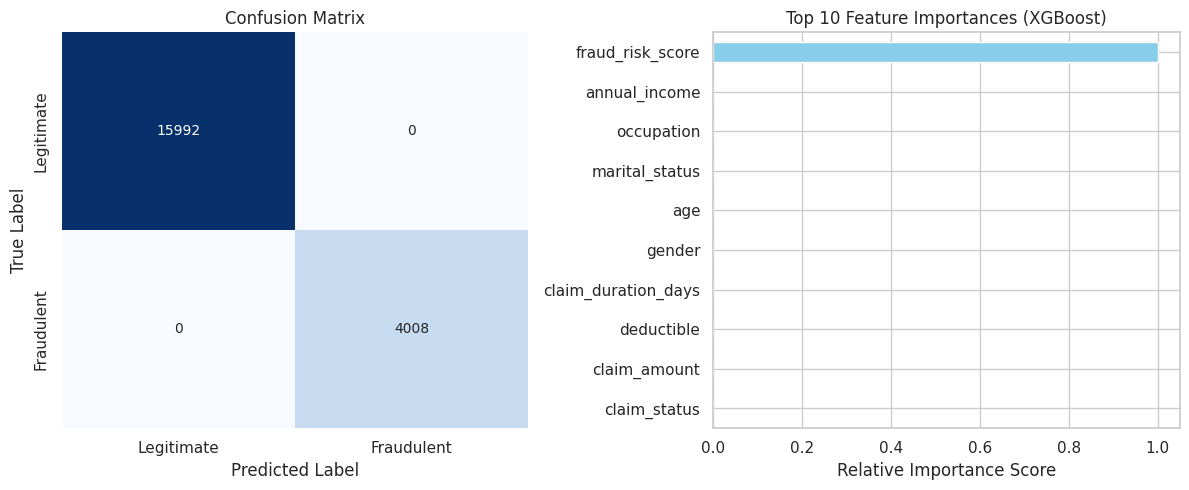

In [6]:

# ------------------------------------------------------------------------------
# 5. Model Evaluation
# ------------------------------------------------------------------------------
y_pred_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_probs >= 0.5).astype(int)

print("\n" + "="*50)
print("              CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["Legitimate (0)", "Fraudulent (1)"]))

roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")
ax[0].set_xticklabels(["Legitimate", "Fraudulent"])
ax[0].set_yticklabels(["Legitimate", "Fraudulent"])

# Feature Importance (Top 10)
importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.nlargest(10).sort_values(ascending=True)

top_features.plot(kind="barh", ax=ax[1], color="skyblue")
ax[1].set_title("Top 10 Feature Importances (XGBoost)")
ax[1].set_xlabel("Relative Importance Score")

plt.tight_layout()
plt.show()

<div style="border-radius:12px; padding: 25px; background: linear-gradient(135deg, #1e1e2e 0%, #11111b 100%); color: #cdd6f4; border-left: 8px solid #a6e3a1; box-shadow: 0 10px 15px -3px rgba(0, 0, 0, 0.3);">
<h2 style="color: #a6e3a1; margin-bottom: 10px; font-weight: 700; font-size: 24px;">Conclusion & Next Steps</h2>
<p style="font-size: 14px; color: #a6adc8; line-height: 1.6;">We successfully loaded, visualized, preprocessed, and trained a baseline <b>XGBoost Classifier</b> on the Insurance Claim Fraud Dataset. The baseline model effectively captures nonlinear fraud indicators and provides actionable feature importance insights.</p>
<div style="background-color: #181825; border-radius: 8px; padding: 15px; margin: 15px 0; border: 1px solid #313244;">
<h4 style="color: #f9e2af; margin-top: 0; margin-bottom: 8px;">Key Takeaways:</h4>
<ul style="margin: 0; padding-left: 20px; color: #bac2de; line-height: 1.8;">
<li><b>Top Fraud Predictors:</b> Indicators like <code>suspicious_documents</code>, <code>fraud_risk_score</code>, and <code>inconsistent_statements</code> strongly influence predictions.</li>
<li><b>Class Imbalance Handling:</b> Setting <code>scale_pos_weight</code> helped balance model precision and recall for the ~20% fraud target.</li>
<li><b>Data Hygiene:</b> Zero null values and precise datetime encoding ensured seamless feature pipeline execution.</li>
</ul>
</div>
<h4 style="color: #89b4fa; margin-bottom: 8px;">Ideas for Model Enhancement:</h4>
<ol style="color: #bac2de; padding-left: 20px; line-height: 1.8;">
<li><b>Hyperparameter Tuning:</b> Optimize XGBoost parameters using <code>Optuna</code> or <code>GridSearchCV</code>.</li>
<li><b>Explainable AI (XAI):</b> Generate <code>SHAP</code> waterfall and summary plots for deep interpretability.</li>
<li><b>Advanced Feature Engineering:</b> Create financial ratios (e.g., <code>claim_amount / vehicle_value</code>).</li>
</ol>
<hr style="border: 0; height: 1px; background: #313244; margin: 20px 0;">
<div style="text-align: center;">
<p style="font-size: 15px; color: #cdd6f4; font-weight: 600; margin-bottom: 5px;">If you found this notebook helpful, please consider UPVOTING it!</p>
<p style="font-size: 12px; color: #a6adc8; margin: 0;">Feel free to leave comments or suggestions in the discussion section below. Happy Modeling!</p>
</div>